# O3b Run – Validation Diagnostics

Best checkpoint: `epoch_79` (lowest validation loss = 0.1222)

**Sections**
1. Setup & load manager
2. Save all per-epoch plots to `run_export/`
3. Loss curves
4. Best epoch – ROC, raw prediction, calibration, joint CDFs
5. PE predictions (tc, mchirp) – no source-param alignment needed
6. Ranking stat vs predicted parameters
7. Cross-epoch: signal/noise separation & output trajectory
8. Benchmark trigger statistics (once inference is done)
9. Source-param diagnostic plots (requires `signal_idx` from updated validation)
10. Run fresh validation for any checkpoint with configurable sample count

In [1]:
import os, sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import expit

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

sys.path.insert(0, os.path.dirname(os.path.abspath('diagnostics.ipynb')))
from config import set_configs
set_configs()

from sage.plotting import ValidationPlotManager

EXPORT_DIR = './run_export'
VAL_H5    = os.path.join(EXPORT_DIR, 'validation_data.h5')
LOSS_H5   = os.path.join(EXPORT_DIR, 'losses.h5')
BEST_EPOCH = 'epoch_0079'

Registered cfg and data_cfg!


## 1 – Load ValidationPlotManager

In [2]:
plotter = ValidationPlotManager(
    validation_h5=VAL_H5,
    losses_h5=LOSS_H5,
    export_dir=EXPORT_DIR,
)

epochs = sorted(plotter.validation_data.keys())
print(f'Epochs loaded : {len(epochs)}  ({epochs[0]} → {epochs[-1]})')
print(f'Source params : {bool(plotter.validation_data[epochs[0]]["source_params"])} '
      '(True only when signal_idx was saved during training)')
print(f'Training loss shape   : {plotter.training_loss.shape}')
print(f'Validation loss shape : {plotter.validation_loss.shape}')

Epochs loaded : 21  (epoch_0000 → epoch_0099)
Source params : False (True only when signal_idx was saved during training)
Training loss shape   : (100, 4)
Validation loss shape : (100, 4)


## 2 – Save all plots to `run_export/`

This writes ROC, raw prediction, calibration, joint CDFs, loss curves, signal/noise separation,
and output trajectory (plus source-param plots when alignment data is available).

In [5]:
plotter.make_all_plots(save=True)
print('Done – check run_export/ for all output directories.')

Done – check run_export/ for all output directories.


## 3 – Loss curves

Best epoch: 1  (val_loss=0.000000)


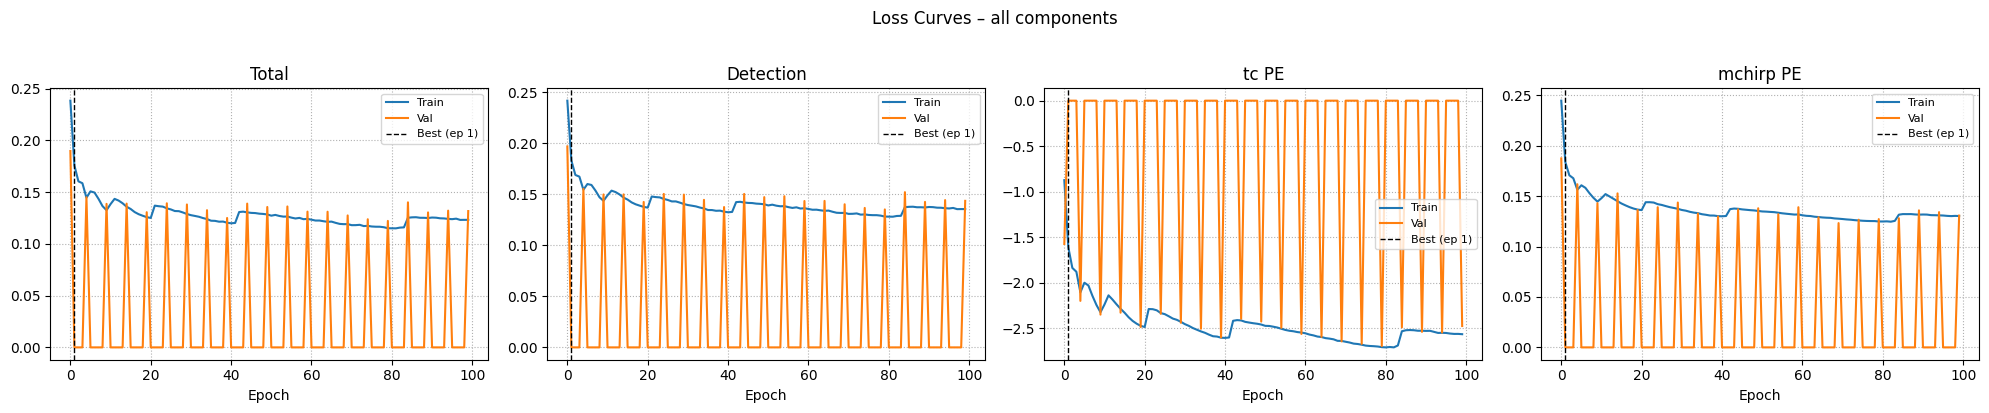

In [6]:
with h5py.File(LOSS_H5, 'r') as fp:
    train_loss = fp['training']['loss'][:]    # (100, 4)
    val_loss   = fp['validation']['loss'][:] # (100, 4)

best_ep = int(np.argmin(val_loss[:, 0]))
print(f'Best epoch: {best_ep}  (val_loss={val_loss[best_ep, 0]:.6f})')

n_components = train_loss.shape[1]
component_names = ['Total', 'Detection', 'tc PE', 'mchirp PE']

fig, axes = plt.subplots(1, n_components, figsize=(5 * n_components, 4))
for i, ax in enumerate(axes):
    ax.plot(train_loss[:, i], label='Train', lw=1.5)
    ax.plot(val_loss[:, i],   label='Val',   lw=1.5)
    ax.axvline(best_ep, color='k', ls='--', lw=1, label=f'Best (ep {best_ep})')
    ax.set_title(component_names[i] if i < len(component_names) else f'Component {i}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, ls=':')
plt.suptitle('Loss Curves – all components', y=1.02)
plt.tight_layout()
plt.show()

## 4 – Best epoch: ROC, raw prediction, calibration, joint CDFs

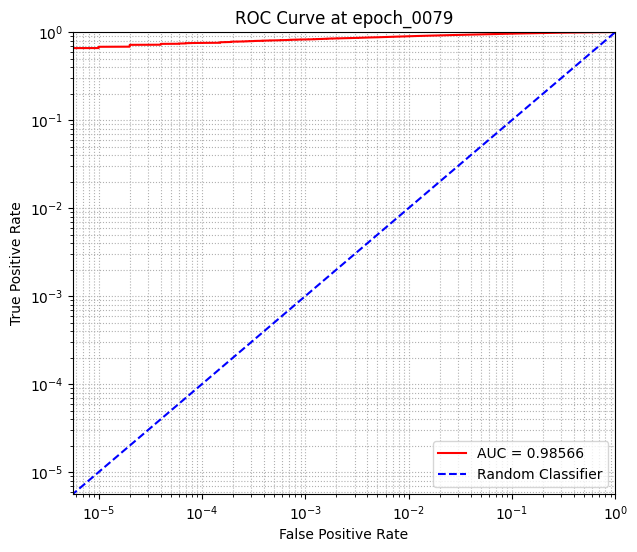

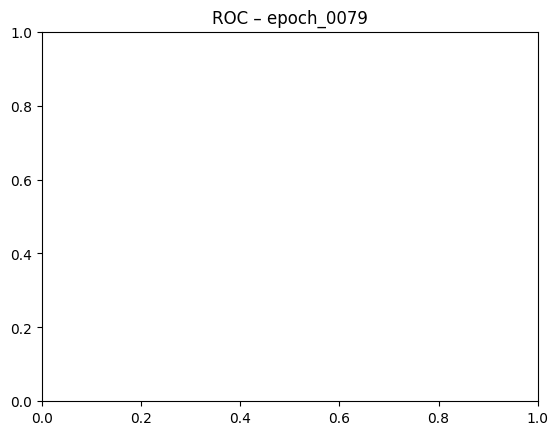

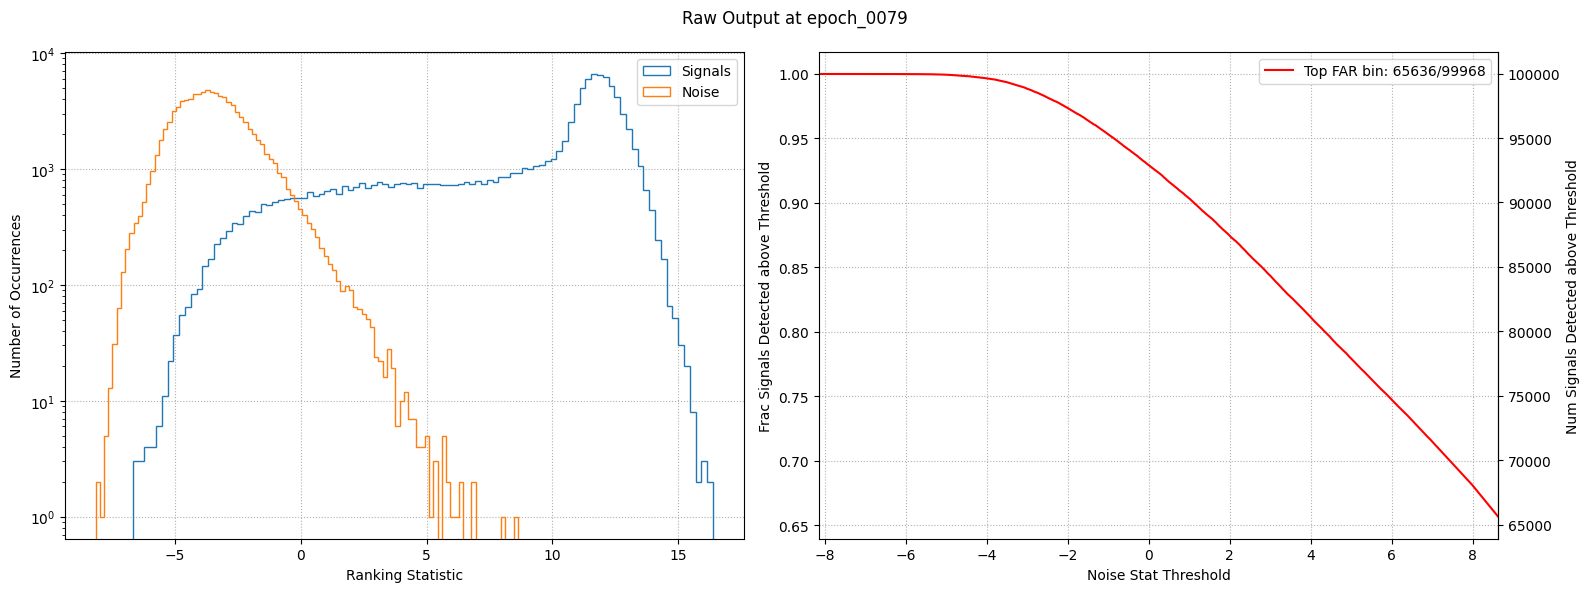

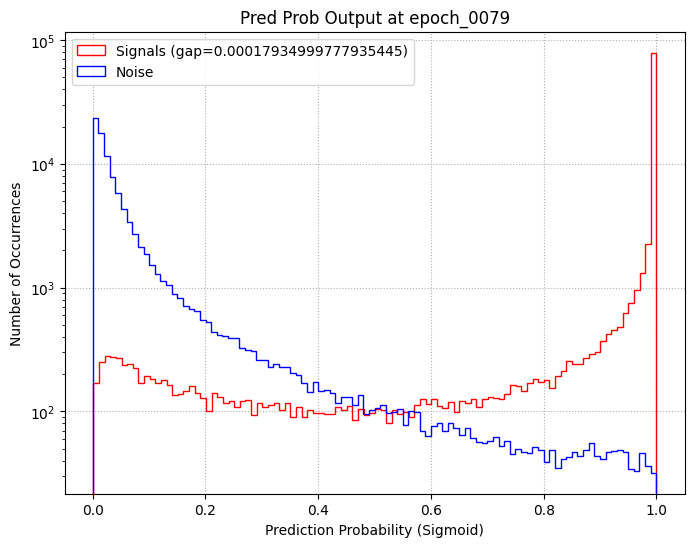

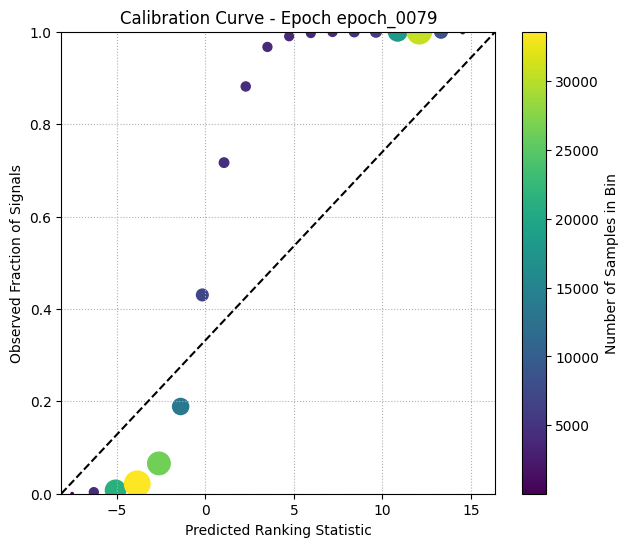

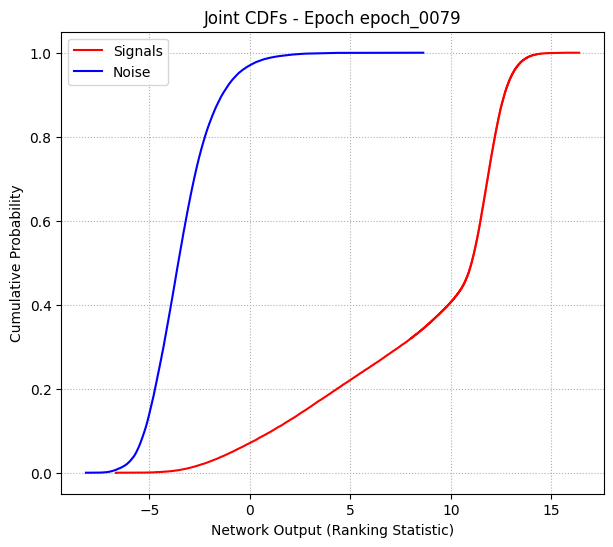

In [7]:
from sage.plotting import (
    plot_roc_curve, plot_prediction_raw, plot_prediction_probability,
    plot_calibration_curve, plot_joint_cdfs
)

d = plotter.validation_data[BEST_EPOCH]

plot_roc_curve(
    epoch=BEST_EPOCH, ranking_stat=d['ranking_stat'], labels=d['labels'],
    export_dir=None, save=False
)
plt.title(f'ROC – {BEST_EPOCH}')
plt.show()

plot_prediction_raw(
    epoch=BEST_EPOCH, ranking_stat=d['ranking_stat'], labels=d['labels'],
    export_dir=None, save=False
)
plt.show()

plot_prediction_probability(
    epoch=BEST_EPOCH, pred_prob=d['pred_prob'], labels=d['labels'],
    export_dir=None, save=False
)
plt.show()

plot_calibration_curve(
    epoch=BEST_EPOCH, ranking_stat=d['ranking_stat'], labels=d['labels'],
    nbins=20, export_dir=None, save=False
)
plt.show()

plot_joint_cdfs(
    epoch=BEST_EPOCH, ranking_stat=d['ranking_stat'], labels=d['labels'],
    export_dir=None, save=False
)
plt.show()

## 5 – PE predictions: tc and mchirp

`network_output` layout (already in physical units, unstandardised during validation):
- col 0: ranking statistic (logit)
- col 1: predicted tc (s)
- col 2: predicted mchirp (M☉)
- col 3: predicted tc σ
- col 4: predicted mchirp σ

These are **per-sample** predictions aligned with `labels`, so no index-shuffling issue applies.

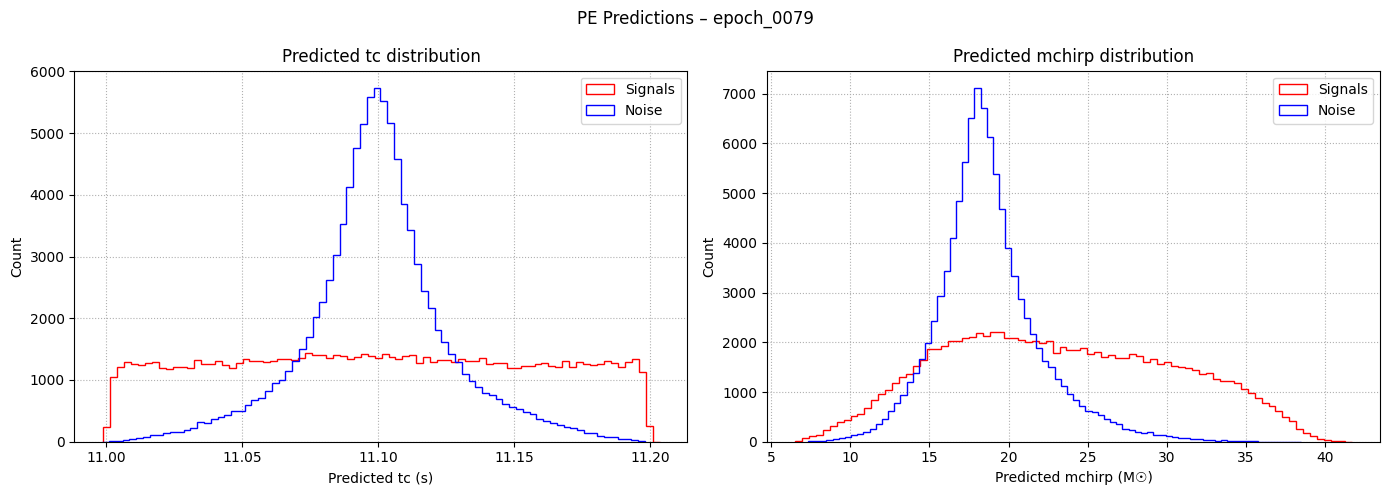

In [8]:
no = d['network_output']   # (N, 5)
labels = d['labels']

sig_mask   = labels == 1.0
noise_mask = labels == 0.0

ranking  = no[:, 0]
tc_pred  = no[:, 1]
mc_pred  = no[:, 2]
tc_sigma = no[:, 3]
mc_sigma = no[:, 4]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PE Predictions – {BEST_EPOCH}')

# tc distribution
ax = axes[0]
ax.hist(tc_pred[sig_mask],   bins=80, histtype='step', label='Signals', color='red')
ax.hist(tc_pred[noise_mask], bins=80, histtype='step', label='Noise',   color='blue')
ax.set_xlabel('Predicted tc (s)')
ax.set_ylabel('Count')
ax.set_title('Predicted tc distribution')
ax.legend()
ax.grid(True, ls=':')

# mchirp distribution
ax = axes[1]
ax.hist(mc_pred[sig_mask],   bins=80, histtype='step', label='Signals', color='red')
ax.hist(mc_pred[noise_mask], bins=80, histtype='step', label='Noise',   color='blue')
ax.set_xlabel('Predicted mchirp (M☉)')
ax.set_ylabel('Count')
ax.set_title('Predicted mchirp distribution')
ax.legend()
ax.grid(True, ls=':')

plt.tight_layout()
plt.show()

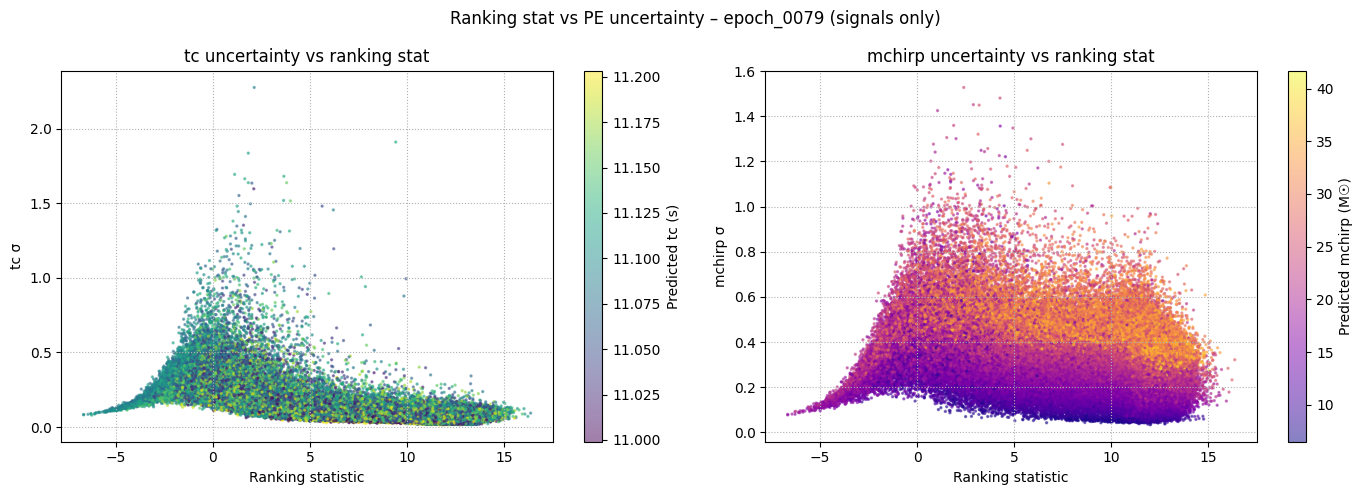

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Ranking stat vs PE uncertainty – {BEST_EPOCH} (signals only)')

sc = axes[0].scatter(
    ranking[sig_mask], tc_sigma[sig_mask],
    c=tc_pred[sig_mask], cmap='viridis', s=2, alpha=0.5
)
plt.colorbar(sc, ax=axes[0], label='Predicted tc (s)')
axes[0].set_xlabel('Ranking statistic')
axes[0].set_ylabel('tc σ')
axes[0].set_title('tc uncertainty vs ranking stat')
axes[0].grid(True, ls=':')

sc = axes[1].scatter(
    ranking[sig_mask], mc_sigma[sig_mask],
    c=mc_pred[sig_mask], cmap='plasma', s=2, alpha=0.5
)
plt.colorbar(sc, ax=axes[1], label='Predicted mchirp (M☉)')
axes[1].set_xlabel('Ranking statistic')
axes[1].set_ylabel('mchirp σ')
axes[1].set_title('mchirp uncertainty vs ranking stat')
axes[1].grid(True, ls=':')

plt.tight_layout()
plt.show()

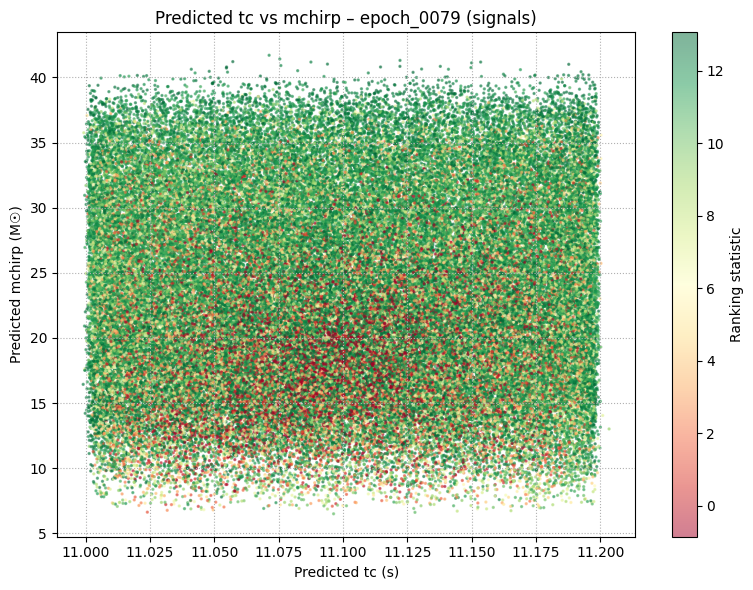

In [10]:
# 2D scatter: tc vs mchirp predictions, coloured by ranking stat
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    tc_pred[sig_mask], mc_pred[sig_mask],
    c=ranking[sig_mask], cmap='RdYlGn', s=2, alpha=0.5,
    vmin=np.percentile(ranking[sig_mask], 5),
    vmax=np.percentile(ranking[sig_mask], 95),
)
plt.colorbar(sc, label='Ranking statistic')
ax.set_xlabel('Predicted tc (s)')
ax.set_ylabel('Predicted mchirp (M☉)')
ax.set_title(f'Predicted tc vs mchirp – {BEST_EPOCH} (signals)')
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

### Evolution of PE predictions across epochs

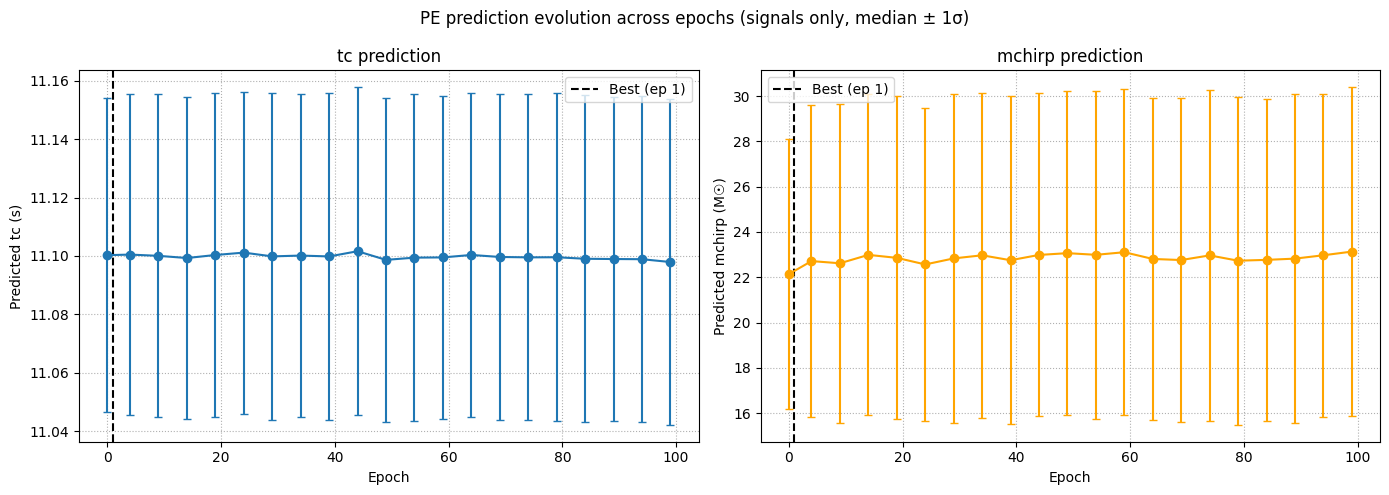

In [11]:
# Track median predicted tc and mchirp (signals only) across epochs
ep_nums   = []
tc_medians, tc_stds = [], []
mc_medians, mc_stds = [], []

for ek in epochs:
    no_ek = plotter.validation_data[ek]['network_output']
    lb_ek = plotter.validation_data[ek]['labels']
    sm    = lb_ek == 1.0
    ep_nums.append(int(ek.split('_')[-1]))
    tc_medians.append(np.median(no_ek[sm, 1]))
    tc_stds.append(np.std(no_ek[sm, 1]))
    mc_medians.append(np.median(no_ek[sm, 2]))
    mc_stds.append(np.std(no_ek[sm, 2]))

tc_medians = np.array(tc_medians); tc_stds = np.array(tc_stds)
mc_medians = np.array(mc_medians); mc_stds = np.array(mc_stds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PE prediction evolution across epochs (signals only, median ± 1σ)')

axes[0].errorbar(ep_nums, tc_medians, yerr=tc_stds, fmt='o-', capsize=3)
axes[0].axvline(best_ep, color='k', ls='--', label=f'Best (ep {best_ep})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Predicted tc (s)')
axes[0].set_title('tc prediction'); axes[0].legend(); axes[0].grid(True, ls=':')

axes[1].errorbar(ep_nums, mc_medians, yerr=mc_stds, fmt='o-', capsize=3, color='orange')
axes[1].axvline(best_ep, color='k', ls='--', label=f'Best (ep {best_ep})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Predicted mchirp (M☉)')
axes[1].set_title('mchirp prediction'); axes[1].legend(); axes[1].grid(True, ls=':')

plt.tight_layout()
plt.show()

## 6 – Ranking statistic vs predicted parameters (all epochs)

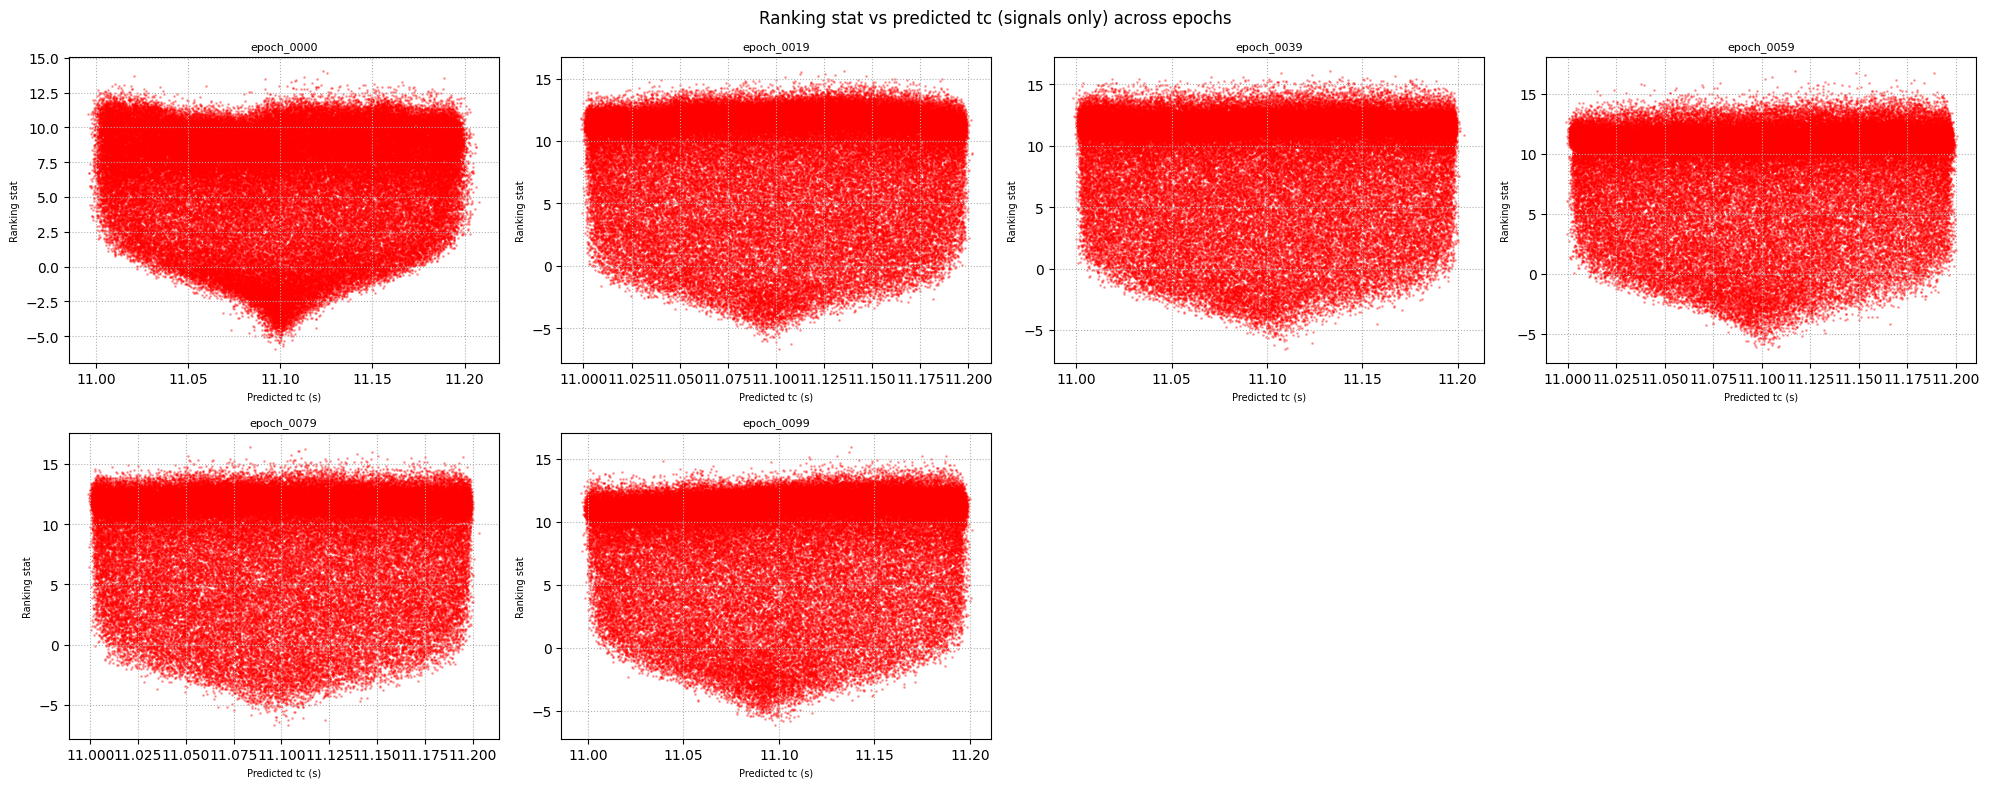

In [12]:
# Show ranking stat vs predicted tc and mchirp for a handful of checkpointed epochs
sel_epochs = epochs[::4]  # every 4th epoch
n = len(sel_epochs)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.atleast_2d(axes)
fig.suptitle('Ranking stat vs predicted tc (signals only) across epochs')

for i, ek in enumerate(sel_epochs):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    no_ek = plotter.validation_data[ek]['network_output']
    lb_ek = plotter.validation_data[ek]['labels']
    sm = lb_ek == 1.0
    ax.scatter(no_ek[sm, 1], no_ek[sm, 0], s=1, alpha=0.3, c='red')
    ax.set_title(ek, fontsize=8)
    ax.set_xlabel('Predicted tc (s)', fontsize=7)
    ax.set_ylabel('Ranking stat', fontsize=7)
    ax.grid(True, ls=':')

for i in range(n, rows * cols):
    r, c = divmod(i, cols)
    axes[r, c].set_visible(False)

plt.tight_layout()
plt.show()

## 7 – Cross-epoch: signal/noise separation & output trajectory

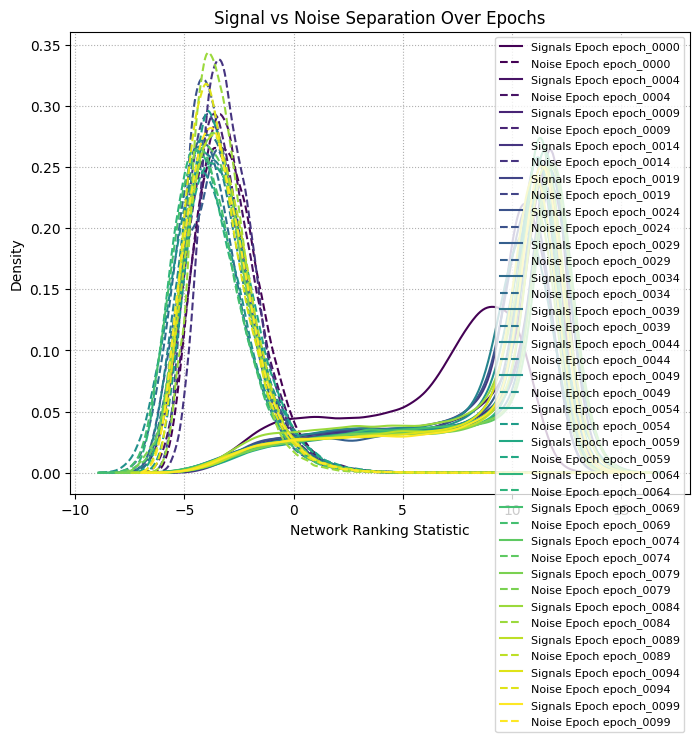

In [13]:
from sage.plotting import plot_separation_over_epochs, plot_output_trajectory_over_epochs

all_stats  = {ek: plotter.validation_data[ek]['ranking_stat'] for ek in epochs}
all_labels = {ek: plotter.validation_data[ek]['labels']       for ek in epochs}

plot_separation_over_epochs(
    all_network_outputs=all_stats,
    all_labels=all_labels,
    epochs=epochs,
    export_dir=None,
    save=False,
)
plt.show()

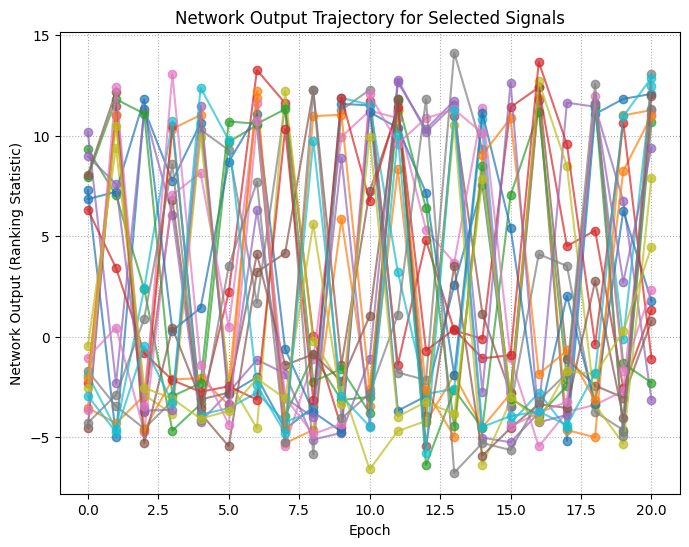

In [14]:
last_labels = plotter.validation_data[epochs[-1]]['labels']
plot_output_trajectory_over_epochs(
    all_ranking_stats=[plotter.validation_data[ek]['ranking_stat'] for ek in epochs],
    labels=last_labels,
    epoch_list=list(range(len(epochs))),
    export_dir=None,
    save=False,
)
plt.show()

## 8 – Benchmark trigger statistics

Reads `run_export/benchmark-mlgwsc1/bg_events.hdf` and `fg_events.hdf` once inference completes.

In [15]:
BG_FILE = os.path.join(EXPORT_DIR, 'benchmark-mlgwsc1', 'bg_events.hdf')
FG_FILE = os.path.join(EXPORT_DIR, 'benchmark-mlgwsc1', 'fg_events.hdf')

if not (os.path.exists(BG_FILE) and os.path.exists(FG_FILE)):
    print('Benchmark inference still running – check back later.')
else:
    with h5py.File(BG_FILE, 'r') as fp:
        bg_stat = fp['stat'][:]
        bg_time = fp['time'][:]
    with h5py.File(FG_FILE, 'r') as fp:
        fg_stat = fp['stat'][:]
        fg_time = fp['time'][:]

    print(f'Background triggers : {len(bg_stat):,}')
    print(f'Foreground triggers : {len(fg_stat):,}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('MLGWSC-1 Benchmark – clustered trigger statistics')

    # Stat histogram
    all_min = min(bg_stat.min(), fg_stat.min())
    all_max = max(bg_stat.max(), fg_stat.max())
    bins = np.linspace(all_min, all_max, 60)
    axes[0].hist(bg_stat, bins=bins, histtype='step', label=f'Background ({len(bg_stat):,})', lw=1.5)
    axes[0].hist(fg_stat, bins=bins, histtype='step', label=f'Foreground ({len(fg_stat):,})', lw=1.5)
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Ranking statistic (logit)')
    axes[0].set_ylabel('Clustered triggers')
    axes[0].legend()
    axes[0].grid(True, ls=':')

    # FAR curve
    # Estimate FAR from background: sort descending, count triggers above threshold
    # Duration of testing dataset assumed 1 month ≈ 2.628e6 s
    T_BG = 2_628_000.0
    sorted_bg = np.sort(bg_stat)[::-1]
    far = np.arange(1, len(sorted_bg) + 1) / T_BG  # events per second

    # Fraction of foreground above each background threshold
    fg_eff = [np.mean(fg_stat > t) for t in sorted_bg]

    axes[1].plot(far, fg_eff, lw=1.5, color='darkorange')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('FAR (events/s)')
    axes[1].set_ylabel('Foreground detection efficiency')
    axes[1].set_title('Efficiency vs FAR')
    axes[1].grid(True, ls=':')

    plt.tight_layout()
    plt.show()

Benchmark inference still running – check back later.


## 9 – Source-param diagnostic plots

These require `signal_idx` to be saved during validation (now implemented in `validation.py`).
Re-run training or validation with the updated code and the cells below will activate automatically.

In [16]:
from sage.plotting import (
    plot_efficiency_curves, plot_learning_parameter_prior,
    plot_outputbin_param_distribution, plot_paramfrac_detected_above_thresh,
    plot_output_vs_param_heatmap, plot_correlation_matrix, plot_cumulative_volume
)

sp = plotter.validation_data[BEST_EPOCH]['source_params']

if not sp:
    print('source_params not available for this dataset.\n'
          'Rerun validation after updating validation.py to save signal_idx.\n'
          'The new validation.py now saves signal_idx; future runs will populate these plots.')
else:
    d = plotter.validation_data[BEST_EPOCH]

    plot_efficiency_curves(
        epoch=BEST_EPOCH,
        source_params=sp,
        pred_stat=d['ranking_stat'],
        labels=d['labels'],
        export_dir=None,
        save=False,
        save_name='ranking_stat',
    )
    plt.show()

    plot_cumulative_volume(
        epoch=BEST_EPOCH,
        ranking_stat=d['ranking_stat'],
        labels=d['labels'],
        source_params=sp,
        export_dir=None,
        save=False,
    )
    plt.show()

    plot_correlation_matrix(
        ranking_stat=d['ranking_stat'],
        source_params={k: sp[k] for k in ('distance','mchirp','tc','inclination','q') if k in sp},
        labels=d['labels'],
        export_dir=None,
        save=False,
        epoch=BEST_EPOCH,
    )
    plt.show()

    plot_paramfrac_detected_above_thresh(
        epoch=BEST_EPOCH,
        ranking_stat=d['ranking_stat'],
        labels=d['labels'],
        sample_params={k: sp[k] for k in ('distance','mchirp','tc') if k in sp},
        export_dir=None,
        save=False,
    )
    plt.show()

source_params not available for this dataset.
Rerun validation after updating validation.py to save signal_idx.
The new validation.py now saves signal_idx; future runs will populate these plots.


## 10 – Run fresh validation for any checkpoint

Load any saved epoch checkpoint and run a validation pass with a configurable number of samples.
`validate_checkpoint.py` works both as an importable module and as a CLI script:

```bash
python3 validate_checkpoint.py --epoch 79 --num-samples 20000
python3 validate_checkpoint.py --epoch 79 --num-samples 20000 --save val_ep79.h5
```

In [4]:
from validate_checkpoint import run_checkpoint_validation

# ── Configure here ────────────────────────────────────────────────────────────
EPOCH       = 79       # epoch number (or full path to .pt file)
NUM_SAMPLES = 200000   # total samples; rounded up to nearest batch (128)
SAVE_PATH   = None     # e.g. './run_export/val_ep79_quick.h5' to persist results
# ─────────────────────────────────────────────────────────────────────────────

result = run_checkpoint_validation(
    epoch=EPOCH,
    num_samples=NUM_SAMPLES,
    save_path=SAVE_PATH,
    verbose=True,
)

print(f"\nEpoch loaded    : {result['epoch_loaded']}")
print(f"Val loss (ckpt) : {result['val_loss']:.6f}")
print(f"Avg loss (run)  : {result['avg_loss_run']:.6f}")
print(f"Total samples   : {result['num_samples']:,}")
sig_mask = result['labels'] == 1.0
print(f"Signals / Noise : {sig_mask.sum():,} / {(~sig_mask).sum():,}")
print(f"Ranking stat range : [{result['ranking_stat'].min():.3f}, {result['ranking_stat'].max():.3f}]")

Checkpoint : /home/nnarenraju/Research/sage/runs/o3b/run_export/CHECKPOINTS/epoch_79.pt
Loaded epoch 79  (val_loss=0.122222)
Batch size : 128  (64 signal, 64 noise)
Iterations : 1563  →  200,064 total samples


Validation:   0%|          | 0/1563 [00:00<?, ?it/s]/home/nnarenraju/software/envs/refactor/lib/python3.12/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
Validation: 100%|██████████| 1563/1563 [06:31<00:00,  4.00it/s]

Avg loss over this run : 0.121870  (bce=0.134691, reg=-2.691419, coupling=0.127254)

Epoch loaded    : 79
Val loss (ckpt) : 0.122222
Avg loss (run)  : 0.121870
Total samples   : 200,064
Signals / Noise : 100,032 / 100,032
Ranking stat range : [-7.859, 15.742]


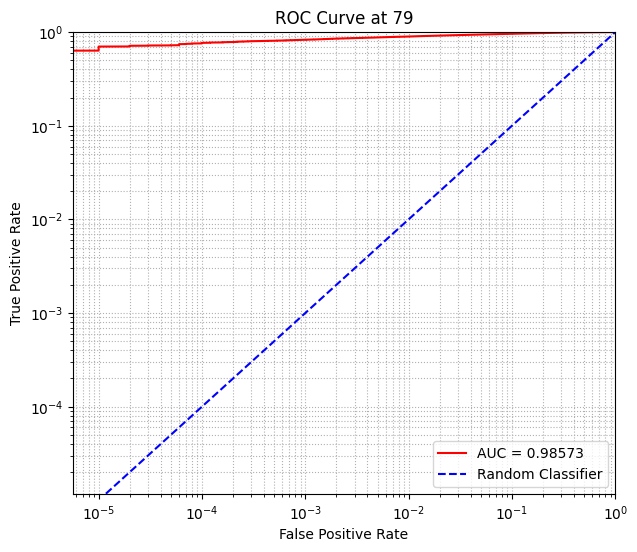

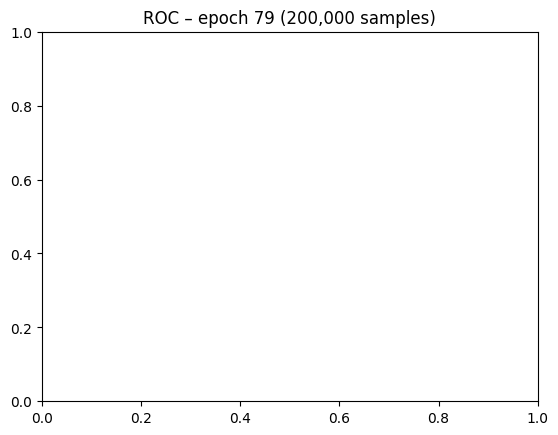

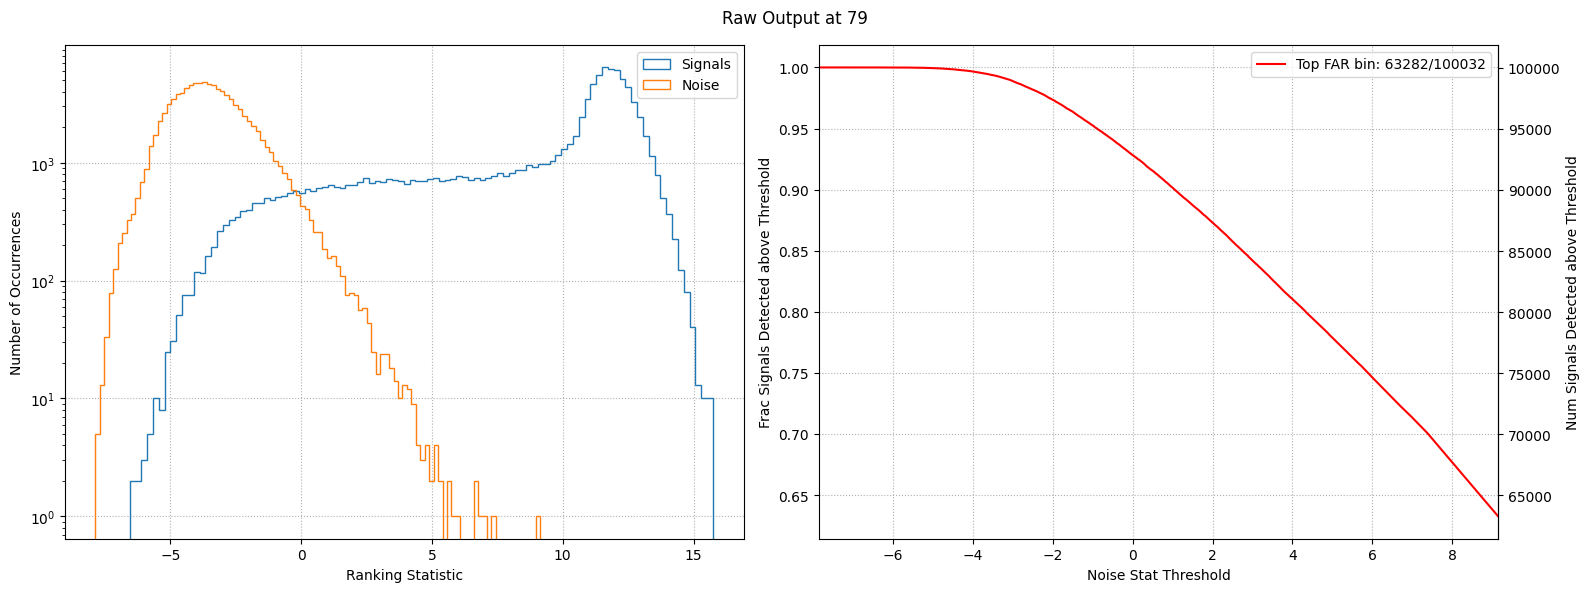

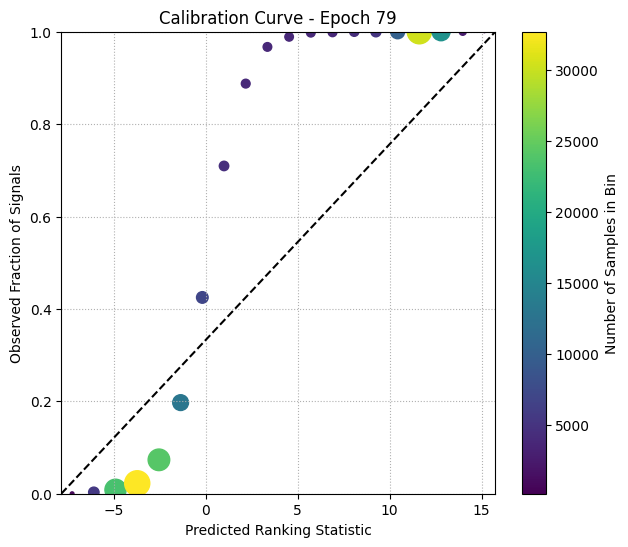

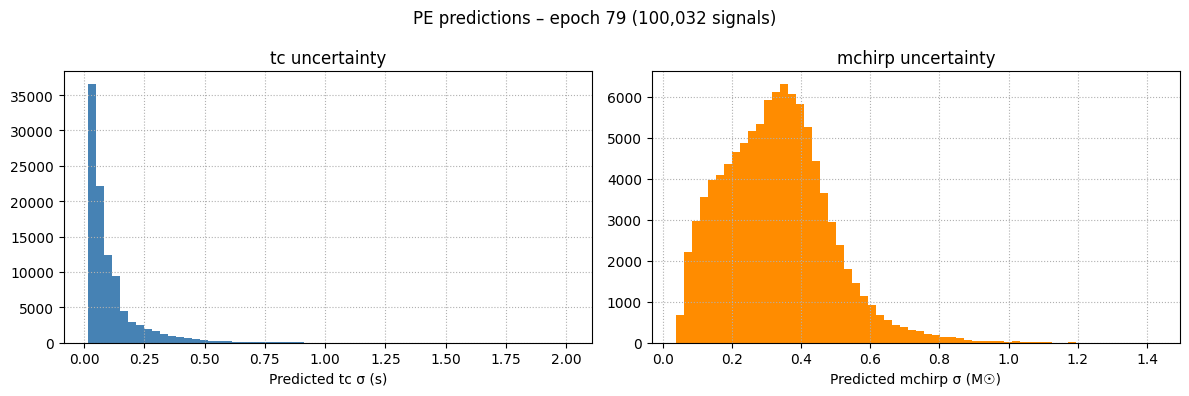

source_params built: ['chirp_distance', 'coa_phase', 'dec', 'distance', 'inclination'] ...
  signals with valid distance: 100,032


In [5]:
# Quick diagnostic plots from the fresh validation result
from validate_checkpoint import build_source_params
from sage.plotting import plot_roc_curve, plot_prediction_raw, plot_calibration_curve

rs  = result['ranking_stat']
lbl = result['labels']
ep  = result['epoch_loaded']

plot_roc_curve(epoch=ep, ranking_stat=rs, labels=lbl, export_dir=None, save=False)
plt.title(f'ROC – epoch {ep} ({NUM_SAMPLES:,} samples)')
plt.show()

plot_prediction_raw(epoch=ep, ranking_stat=rs, labels=lbl, export_dir=None, save=False)
plt.show()

plot_calibration_curve(epoch=ep, ranking_stat=rs, labels=lbl, nbins=20, export_dir=None, save=False)
plt.show()

# PE uncertainty distributions (signals only)
no  = result['network_output']   # (N, 5): ranking, tc, mchirp, tc_sigma, mc_sigma
sm  = lbl == 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'PE predictions – epoch {ep} ({sm.sum():,} signals)')
axes[0].hist(no[sm, 3], bins=60, color='steelblue')
axes[0].set_xlabel('Predicted tc σ (s)'); axes[0].set_title('tc uncertainty'); axes[0].grid(True, ls=':')
axes[1].hist(no[sm, 4], bins=60, color='darkorange')
axes[1].set_xlabel('Predicted mchirp σ (M☉)'); axes[1].set_title('mchirp uncertainty'); axes[1].grid(True, ls=':')
plt.tight_layout()
plt.show()

# Build aligned source params (requires signal_idx in result — always present here)
sp = build_source_params(result)
print(f"source_params built: {list(sp.keys())[:5]} ...")
print(f"  signals with valid distance: {np.isfinite(sp['distance']).sum():,}")

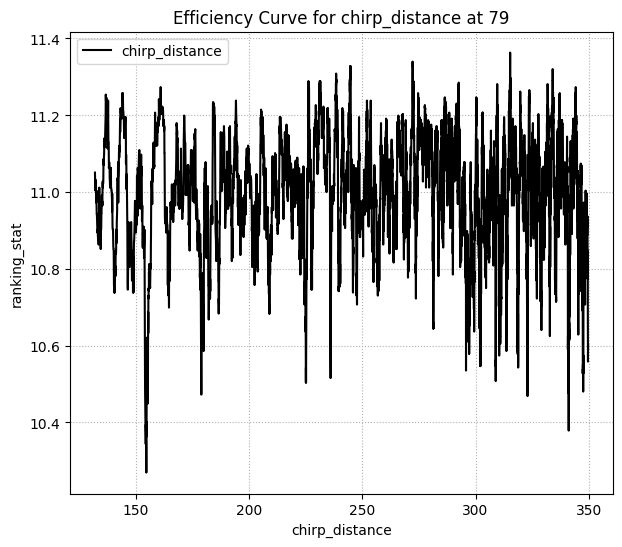

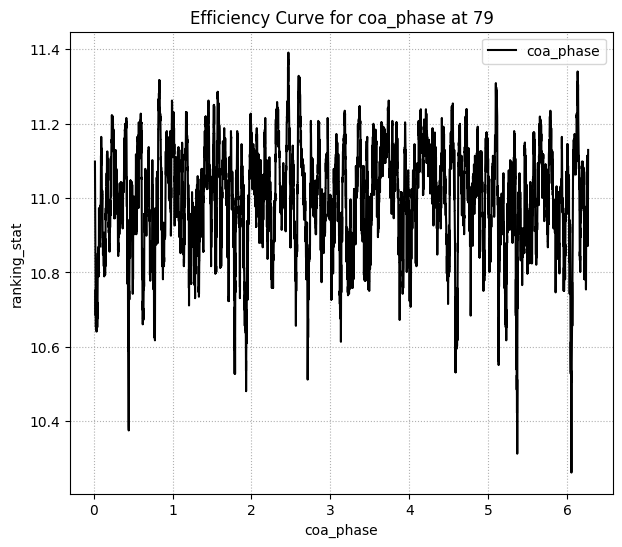

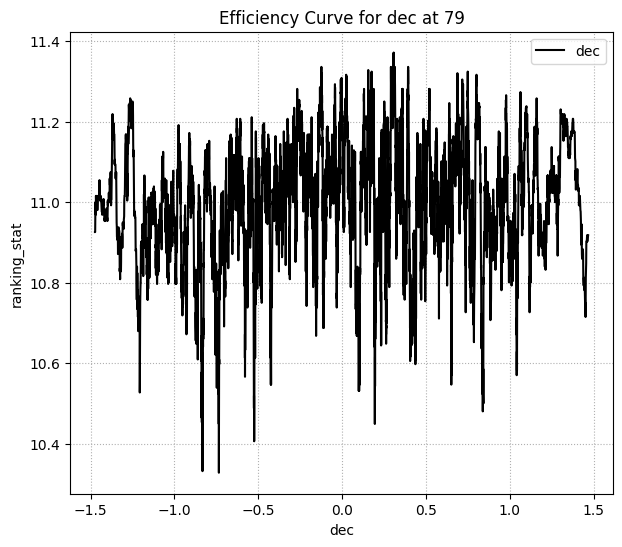

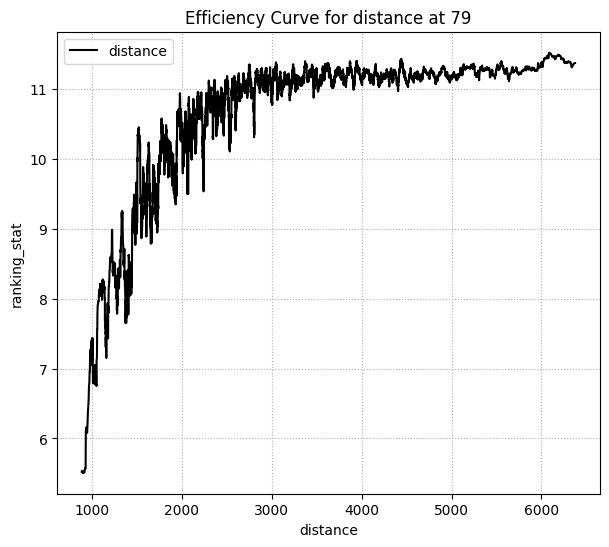

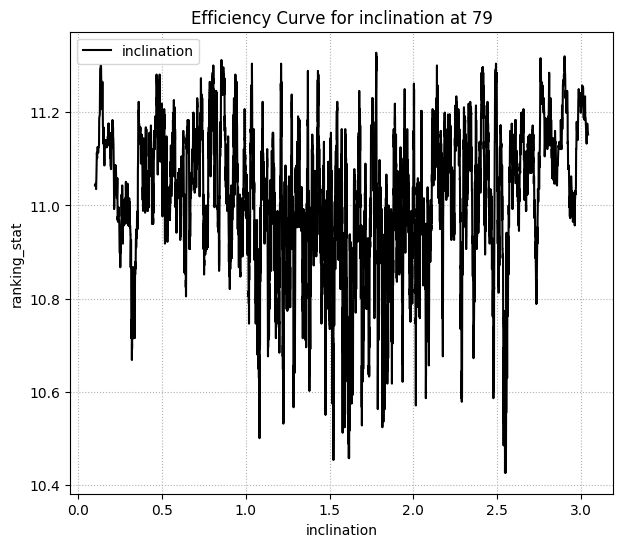

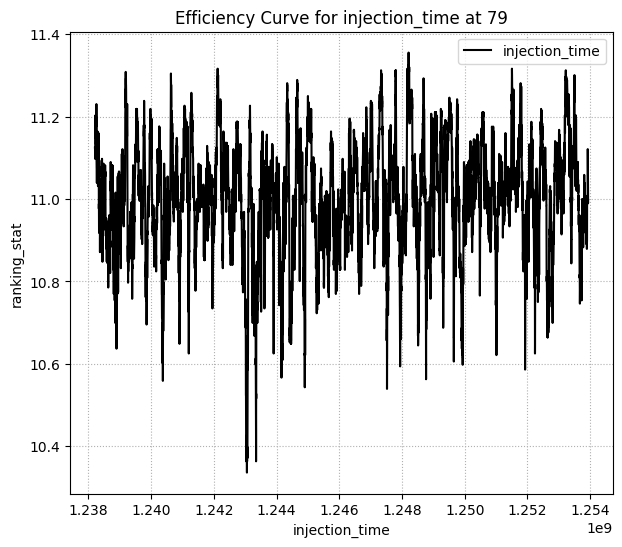

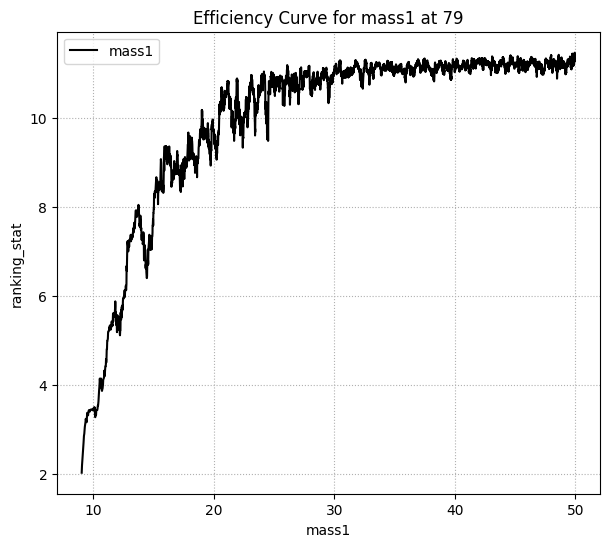

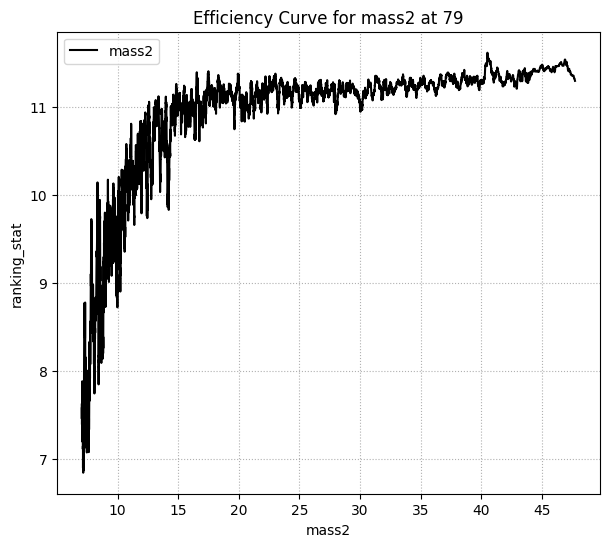

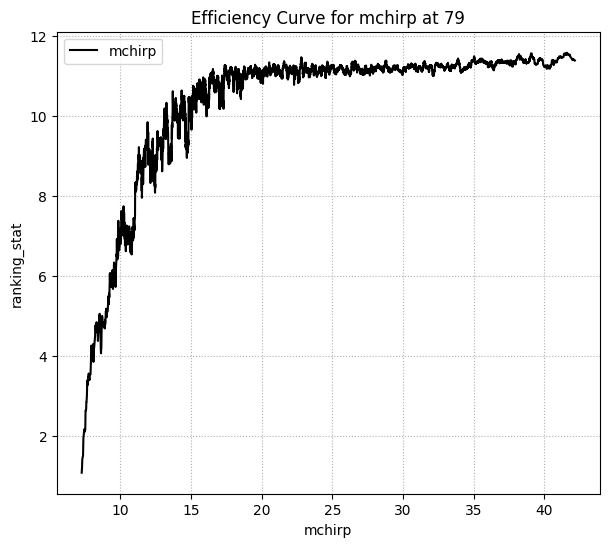

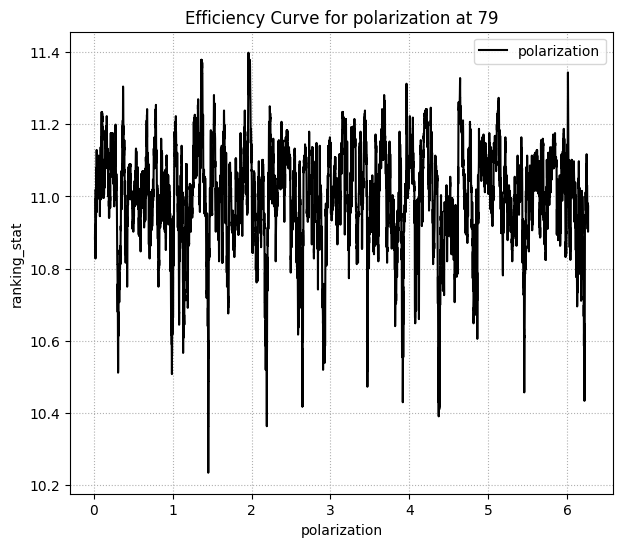

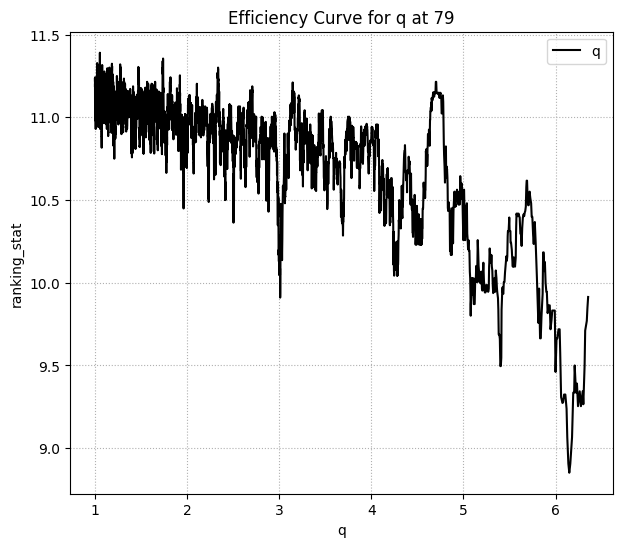

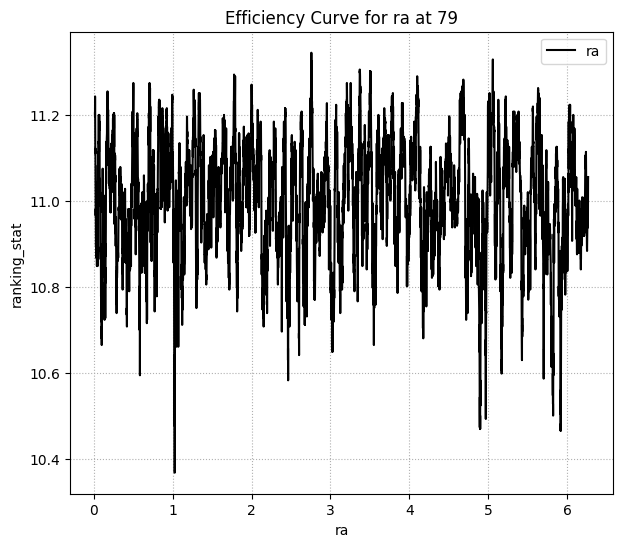

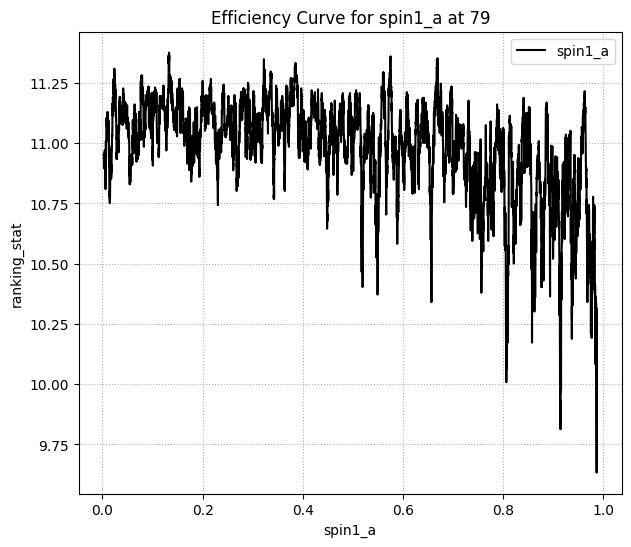

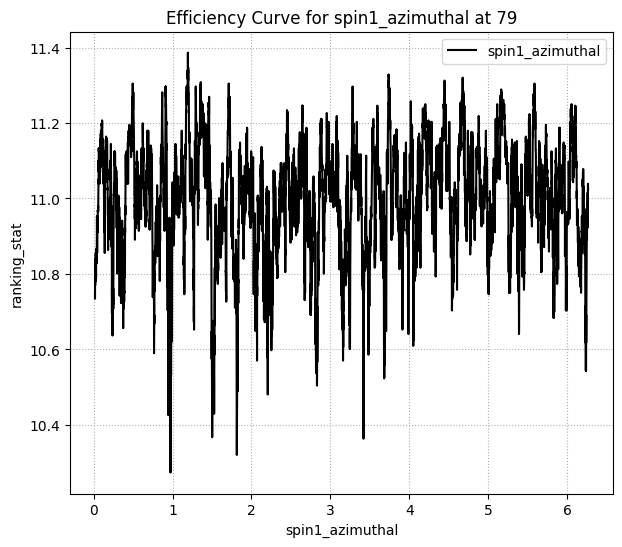

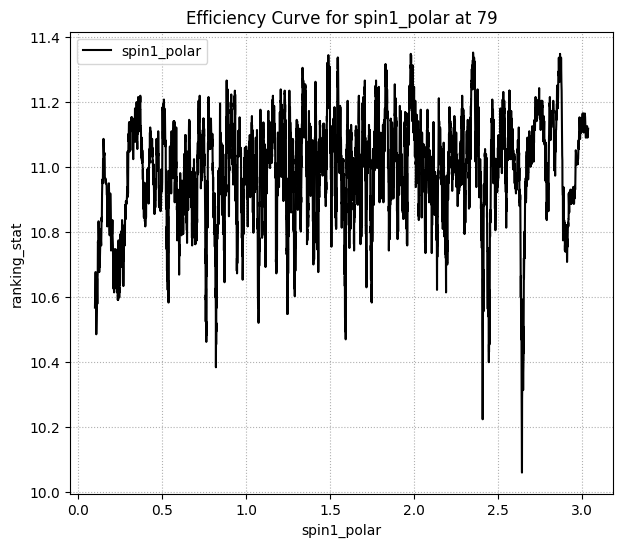

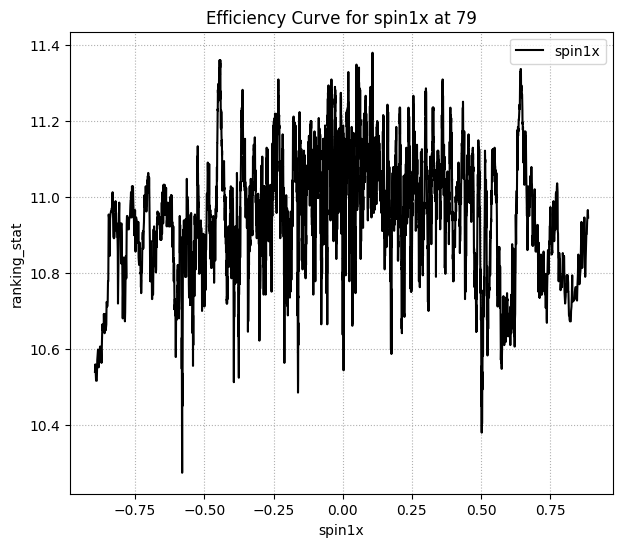

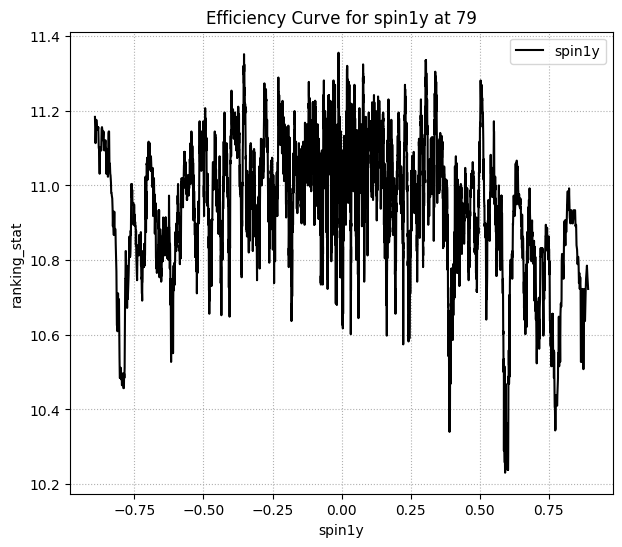

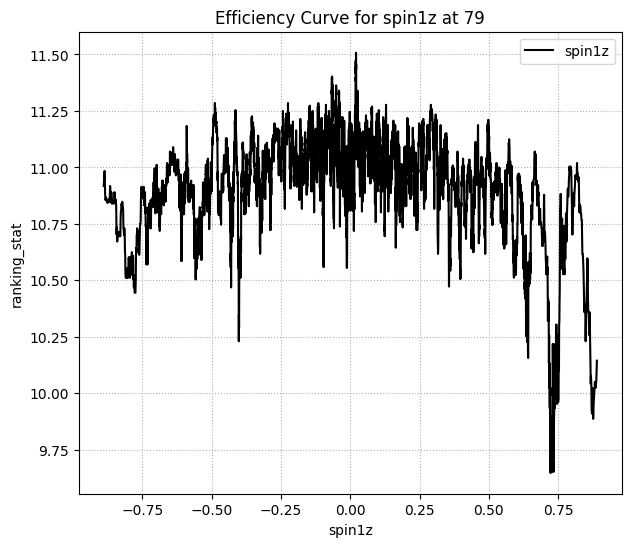

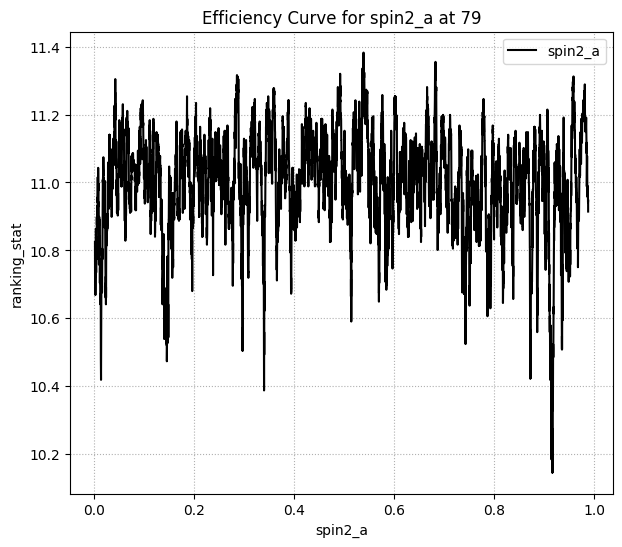

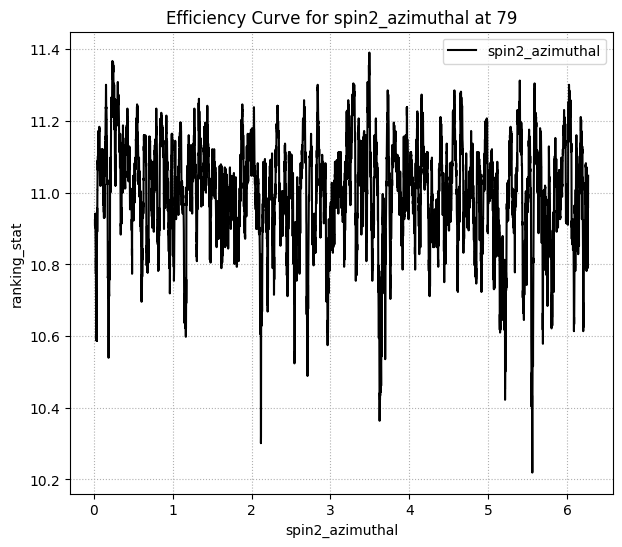

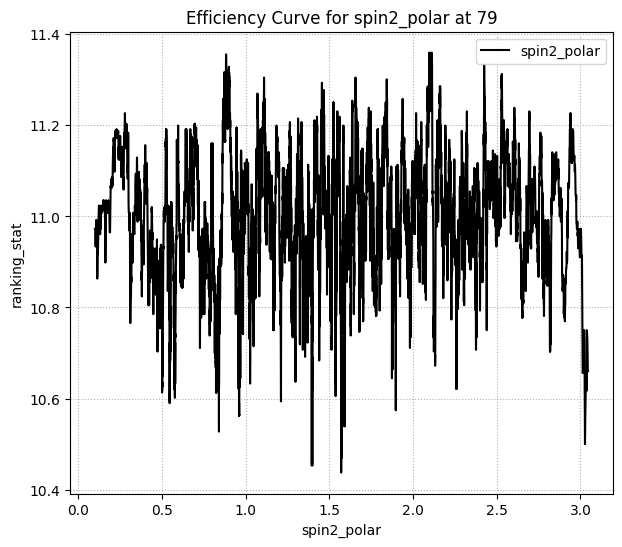

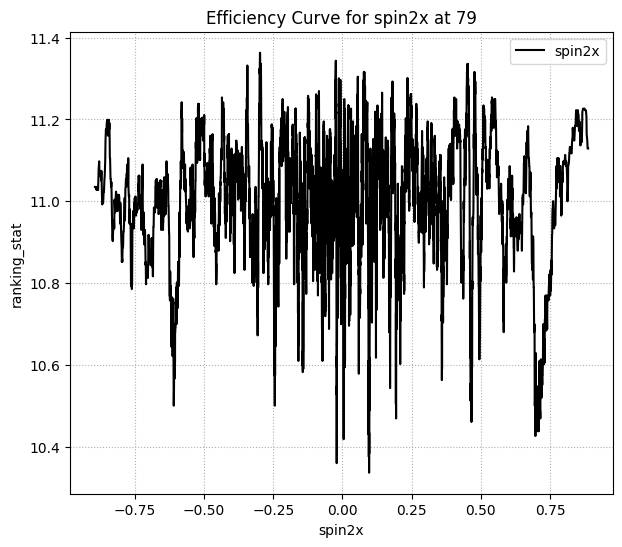

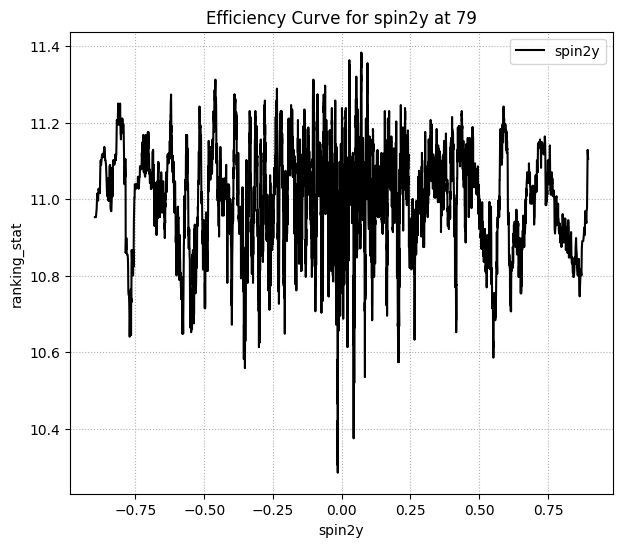

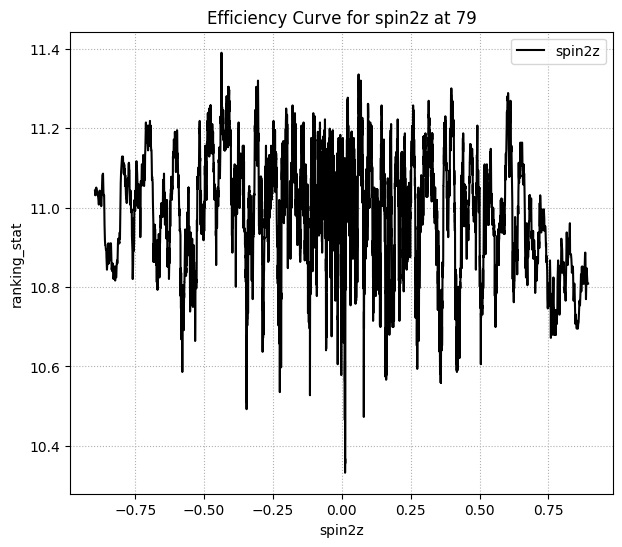

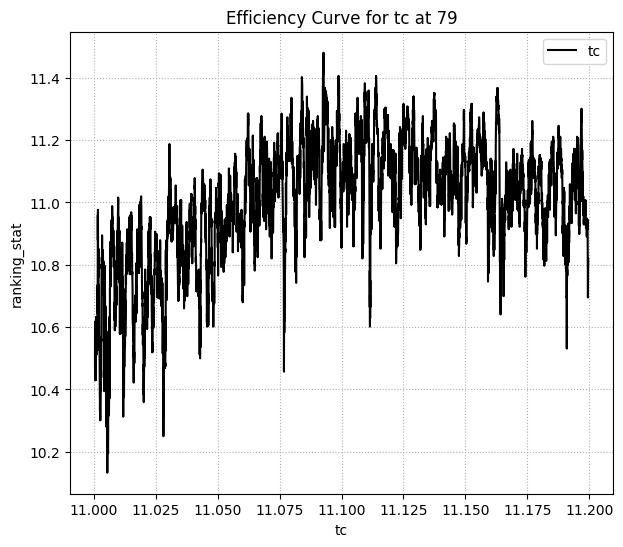

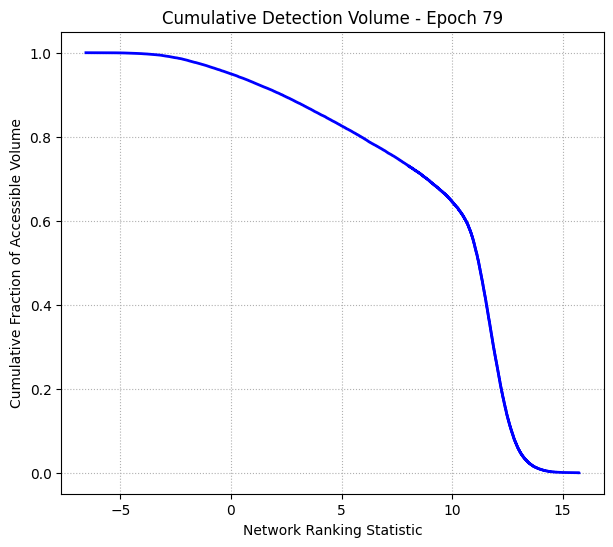

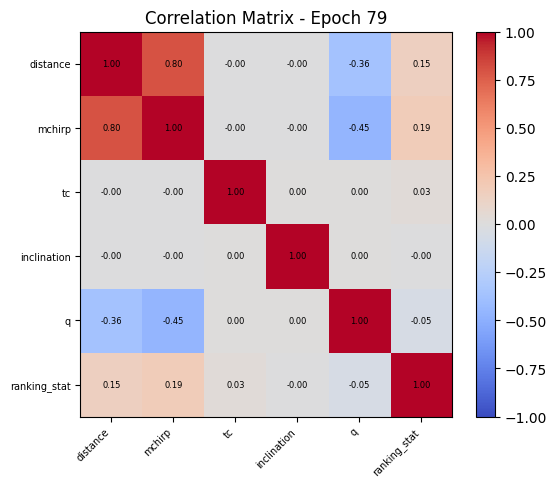

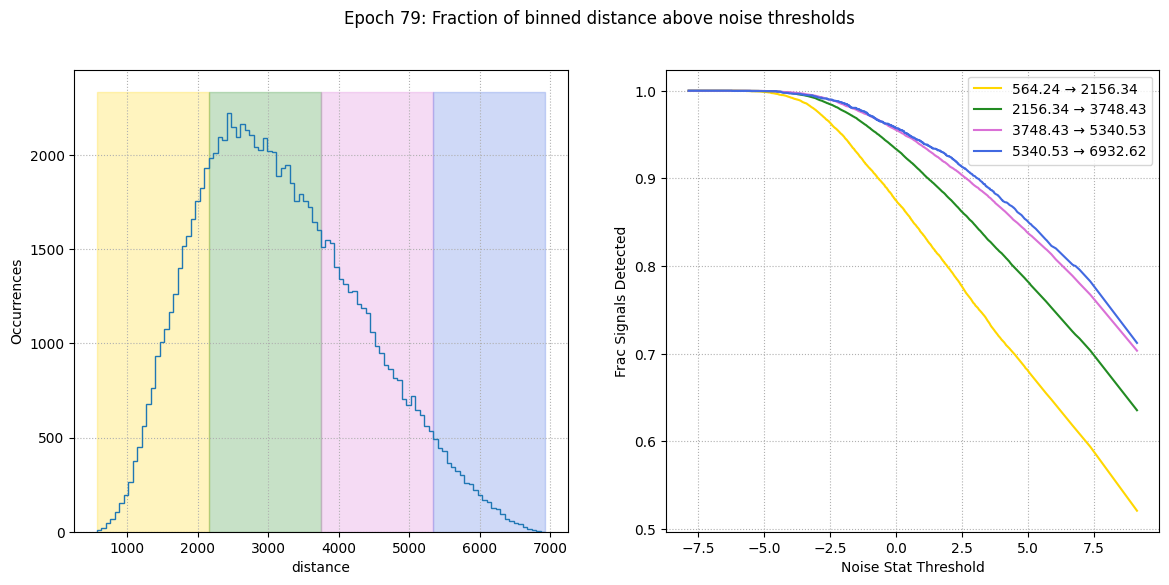

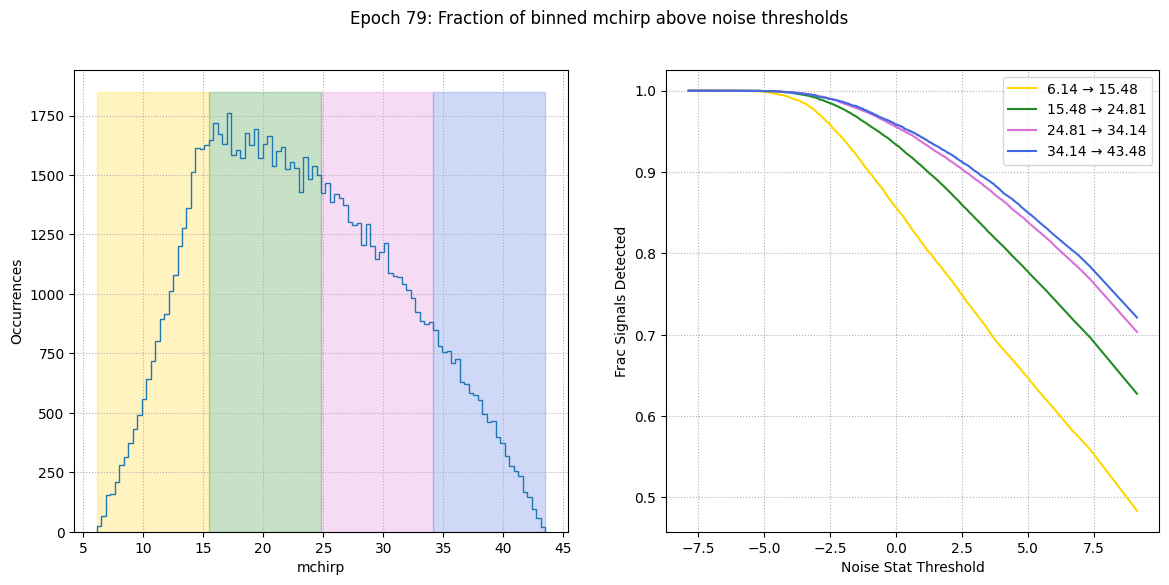

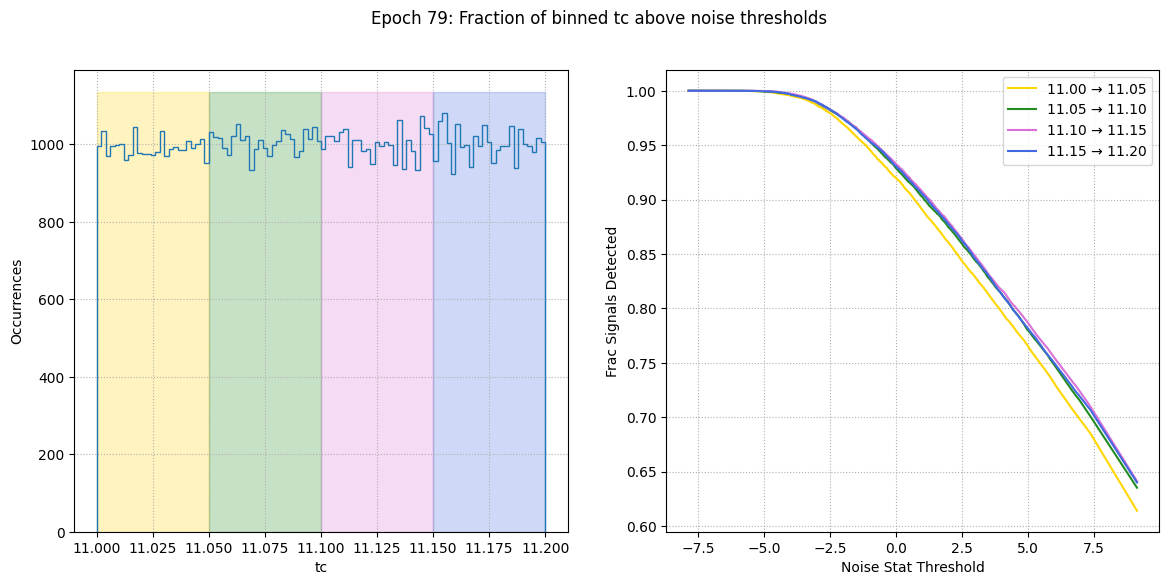

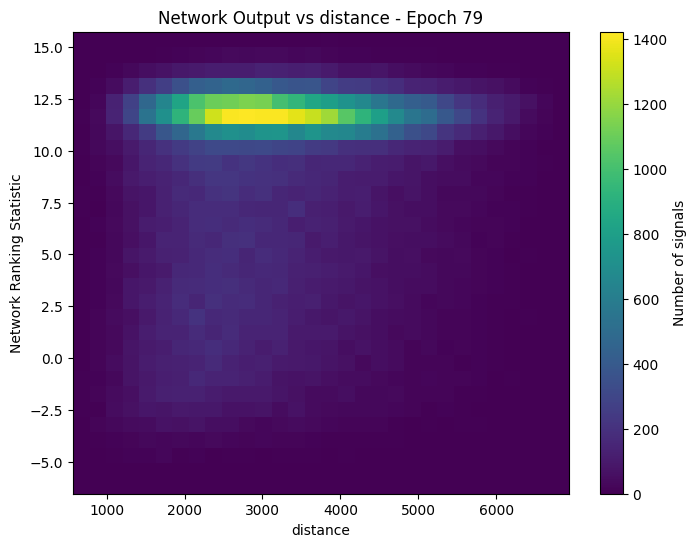

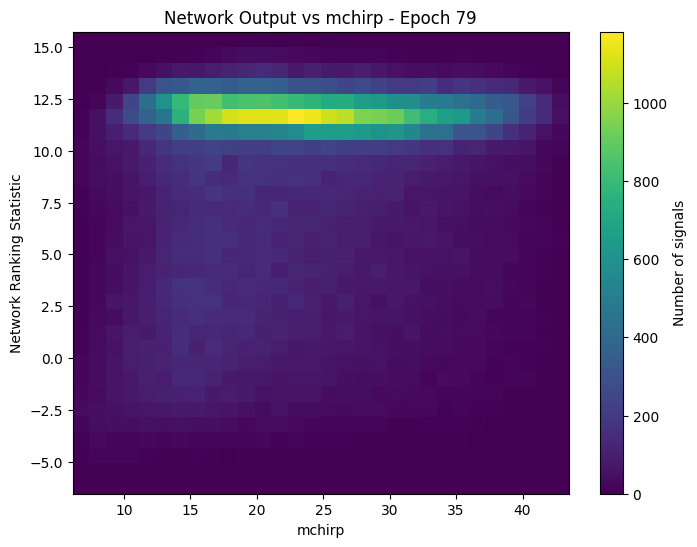

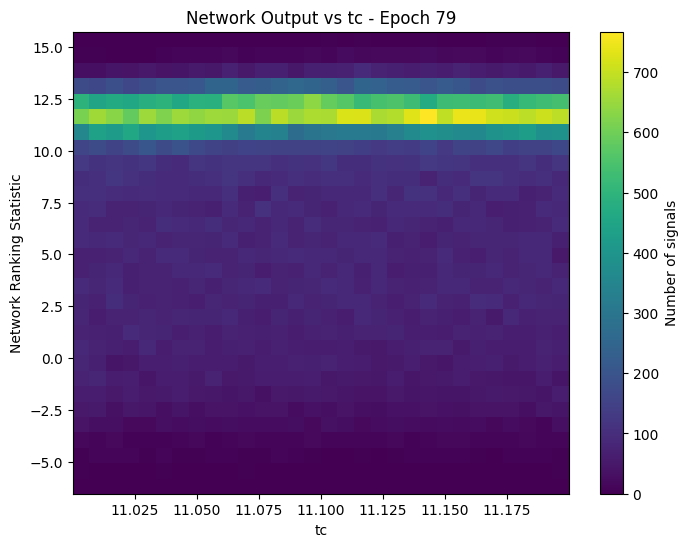

In [6]:
# Source-param diagnostic plots using aligned params from fresh validation
from sage.plotting import (
    plot_efficiency_curves,
    plot_cumulative_volume,
    plot_correlation_matrix,
    plot_paramfrac_detected_above_thresh,
    plot_output_vs_param_heatmap,
)

plot_efficiency_curves(
    epoch=ep,
    source_params=sp,
    pred_stat=rs,
    labels=lbl,
    export_dir=None,
    save=False,
    save_name='ranking_stat',
)
plt.show()

plot_cumulative_volume(
    epoch=ep,
    ranking_stat=rs,
    labels=lbl,
    source_params=sp,
    distance_param='distance',
    export_dir=None,
    save=False,
)
plt.show()

plot_correlation_matrix(
    ranking_stat=rs,
    source_params={k: sp[k] for k in ('distance', 'mchirp', 'tc', 'inclination', 'q') if k in sp},
    labels=lbl,
    export_dir=None,
    save=False,
    epoch=ep,
)
plt.show()

plot_paramfrac_detected_above_thresh(
    epoch=ep,
    ranking_stat=rs,
    labels=lbl,
    sample_params={k: sp[k] for k in ('distance', 'mchirp', 'tc') if k in sp},
    export_dir=None,
    save=False,
)
plt.show()

for param_name in ('distance', 'mchirp', 'tc'):
    if param_name in sp:
        plot_output_vs_param_heatmap(
            epoch=ep,
            ranking_stat=rs,
            labels=lbl,
            source_params=sp,
            param_name=param_name,
            export_dir=None,
            save=False,
        )
        plt.show()